In [1]:
import json
import os
import sys
import time
import pickle 

import numpy as np
import pandas as pd
import squidpy as sq
import scanpy as sc

import anndata as ad

from scipy.stats import spearmanr,pearsonr

# Plotting
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

import stipple as stp
from stipple.model import StippleModel

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
import anndata as ad

Helpers to load data and save results

In [3]:
def load_visium(path, count_file: str) -> ad.AnnData:
    """
    Load a single Visium sample into an AnnData with obsm["spatial"]
    """
    import squidpy as sq
    
    adata = sq.read.visium(
          path,
          counts_file = count_file,
    )
    
    adata.obs['barcode'] = adata.obs.index
    adata.var_names_make_unique()
    
    return adata

    
def _unique_dir(path: str) -> str:
    """`path`, or `path` with a numeric suffix (_1, _2, ...) appended to
    its final component if it already exists -- run directories are
    never overwritten."""
    if not os.path.exists(path):
        return path
    parent, name = os.path.split(path)
    i = 1
    while True:
        candidate = os.path.join(parent, f"{name}_{i}")
        if not os.path.exists(candidate):
            return candidate
        i += 1


def _tidy_fitted_mean_variance(adata) -> pd.DataFrame:
    """Long/tidy format: one row per (observation, gene), columns
    obs_id/gene/fitted_mean/fitted_variance -- melts adata.obsm[
    "stipple_fitted_mean"/"stipple_fitted_variance"] ((N, G) each)."""
    
    mean_ig = np.asarray(adata.obsm["stipple_fitted_mean"])
    var_ig = np.asarray(adata.obsm["stipple_fitted_variance"])
    obs_ids = adata.obs_names.to_numpy()
    gene_names = adata.var_names.to_numpy()
    n, G = mean_ig.shape
    return pd.DataFrame({
        "obs_id": np.repeat(obs_ids, G),
        "gene": np.tile(gene_names, n),
        "fitted_mean": mean_ig.ravel(),
        "fitted_variance": var_ig.ravel(),
    })


Helper for QC of counts

In [4]:
def do_qc_prep(
    adata, 
    * ,
    min_max_val=4, 
    max_max_val=1_000,
    min_mean=0.38,
    min_cells=10,
    max_pct_dropout = 95,
    exclude_top=None,
    output_dir=None,
    copy=False
):

    import scanpy as sc
    # Filter to in tissue spots
    adata.obs['in_tissue'] = adata.obs['in_tissue'].astype(bool)
    adata = adata[adata.obs['in_tissue'],:]
    
    adata.var["mt"] = adata.var_names.str.startswith(("MT-","mt-"))
    adata.var["ribo"] =  adata.var_names.str.startswith(("RPS","RPL"))
    adata.layers['raw'] = adata.X.copy()
    
    adata.var['Symbol'] = adata.var.index

    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt','ribo'],inplace=True)
    sc.pp.filter_genes(adata, min_cells=min_cells)
    
    gene_dropout_pct_filter = adata.var['pct_dropout_by_counts'] < max_pct_dropout

    n, g = adata.shape
    means = adata.X.mean(axis=0).A1
    maxes = adata.X.max(axis=0).toarray().reshape(-1)
    
    gene_min_max_filter = (means >= min_mean) & (maxes <= max_max_val) & (maxes >= min_max_val)
    
    genes_keep_filter = gene_dropout_pct_filter & gene_min_max_filter & (~ adata.var["mt"].values)


    if exclude_top: 
        adata = adata[:, genes_keep_filter].copy()
        
        X = adata.X.copy()
        frac = X / adata.obs['total_counts'].values.reshape(-1,1)
        
        gene_idx_max = np.asarray(np.argmax(frac, axis=1)).flatten()
        high_expr_gene_excl = adata.var_names[gene_idx_max].value_counts().head(n=exclude_top).index.values
    
        print(f"Excluding the top {exclude_top} highest fraction genes:\n {high_expr_gene_excl}")
    
        import csv
       
        with open(os.path.join(output_dir,'exclude-genes.csv'), 'w', newline='', encoding='utf-8') as file:
            writer = csv.writer(file)
            writer.writerow(high_expr_gene_excl)
    
        gene_high_expr_filter = adata.var_names.isin(high_expr_gene_excl)
        genes_keep_filter = (~gene_high_expr_filter)

    n_fit_genes = genes_keep_filter.sum()
    
    print(f"{n_fit_genes} / {g} available for fitting", flush=True)
    
    return adata[:, genes_keep_filter].copy() if copy else adata[:, genes_keep_filter]

In [5]:
output_root = '../results'
dataset_id = 'libd'
sample_id = '151673'
run_id = 'stipple'

Load data and do QC

In [ ]:
# Assume that the full model has already been run

In [7]:
data_file = "151673_filtered_bc_matrix.h5"
data_path = os.path.join("../data/raw/", sample_id, f'{sample_id}_{data_file}')

The output directory with results for the ful mdel

In [8]:
out_dir = os.path.join("../results/libd/151673/stipple")

In [9]:
base_dir = os.path.join(output_root, dataset_id, sample_id, run_id)
out_dir = _unique_dir(base_dir)
os.makedirs(out_dir)

# print(f"Writing results to {out_dir}", flush=True)
out_dir = os.path.join("../results/libd/151673/stipple")

In [10]:
df_layers = pd.read_csv(
    # os.path.abspath(args.path+ "./../LIBD_info/barcode_level_layer_map.tsv"), 
    os.path.abspath(data_path + "./../LIBD_info/barcode_level_layer_map.tsv"), 
    names = ['barcode','sample','layer'], sep='\t')

df_layers['sample'] = df_layers['sample'].astype(str)

In [11]:
adata = load_visium(data_path, data_file)
print(f"Loaded {adata.n_obs} spots x {adata.n_vars} genes", flush=True)

/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/si

Loaded 3639 spots x 33538 genes


In [12]:
adata = do_qc_prep(adata, exclude_top=50, output_dir = out_dir)

adata.obs['sample'] = sample_id

/tmp/ipykernel_1954922/991986356.py:19: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["mt"] = adata.var_names.str.startswith(("MT-","mt-"))


Excluding the top 50 highest fraction genes:
 ['FTH1' 'MBP' 'MT3' 'NRGN' 'SNAP25' 'TMSB10' 'GAPDH' 'ACTB' 'CST3'
 'SCGB2A2' 'COX6C' 'CLU' 'PLP1' 'TUBA1B' 'MTRNR2L12' 'MALAT1' 'RPL41'
 'CALM1' 'CALM2' 'TMSB4X' 'ATP1B1' 'ENC1' 'CCK' 'IGKC' 'SPARCL1' 'NPY'
 'NDUFA4' 'GNAS' 'NEFL' 'HBB' 'VSNL1' 'OLFM1' 'EEF1A1' 'CKB' 'CAMK2N1'
 'GPM6A' 'HBA2' 'CHN1' 'GFAP' 'FTL' 'SLC1A2' 'TUBB2A' 'RTN3' 'YWHAH'
 'UCHL1' 'STMN1' 'GRIN1' 'ACTG1' 'THY1' 'SST']
2077 / 16578 available for fitting


/tmp/ipykernel_1954922/3070456782.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['sample'] = sample_id


In [13]:
adata.obs = pd.merge(adata.obs, df_layers, on=['barcode','sample'], how='left')

adata.obs = adata.obs.set_index('barcode',drop=True)
adata.obs.index.name = None

adata = adata[~adata.obs['layer'].isna(),:]

print(f"QC complete! Fitting {adata.n_obs} spots x {adata.n_vars} genes", flush=True)

QC complete! Fitting 3611 spots x 2077 genes


/home/kayla-jackson/opt/anaconda3/envs/stipple/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [14]:
n,g = adata.shape

Estimate mean capture probability in assay

In [15]:
tc = adata.obs['total_counts'].values
q = tc / np.mean(tc)

tk_i = adata.obs.groupby('layer')['total_counts'].transform('mean').values
tk  = adata.obs.groupby('layer')['total_counts'].mean().values
nk = adata.obs.groupby('layer')['total_counts'].size().values

scalars = (q/n/tk_i) * sum(nk*tk)
if max(scalars) < 1 :
    print("Max scalar is less than 1, estimate of MU_0 is invalid. Model is incorrect")
    
MU_0 = 1 / np.max(scalars)

print(f'Known capture rate set to: {MU_0}', flush=True)

Known capture rate set to: 0.29239382422135424


Model parameters/arguments

In [16]:
fine_resolution_dict = {
    'n_knots_target': n*2,
    "radius_overlap_factor": 1.5
}
coarse_resolution_dict = None

       
model_kwargs = dict(
        group_key="layer",
        likelihood='negbinomial',
        sigma2 = 1.0, 
        fine_resolution=fine_resolution_dict,
        coarse_resolution=coarse_resolution_dict,
        gene_batch_size=100
    )

Run stipple

In [17]:
model = StippleModel(
    adata, 
    known_capture_rate=MU_0, 
    num_threads=16,
    verbose=True,
    **model_kwargs
)

t0 = time.perf_counter()
model.fit(debug=True, n_iterations=3_000, convergence_tol=1e-5)
fit_seconds = time.perf_counter() - t0

model.set_anndata_results(adata)

converged = bool(model._converged)
print(f"Fit finished in {fit_seconds:.1f}s (converged={converged})", flush=True)

[stipple] preprocessing data
[stipple] detected hexagonal grid, spacing=137, 3611 locations, 2077 genes, 7 groups


/home/kayla-jackson/projects/stipple/stipple/model/data.py:135: UserWarning: hexagonal-to-oblique coordinate transform has larger-than-expected residuals for 7.4% of points; the detected lattice orientation may be inaccurate
  coords_transformed, inverse_transform = grid.to_grid_coordinates(coords_raw, grid_info)
/home/kayla-jackson/projects/stipple/stipple/model/stipple_model.py:168: UserWarning: materializing a dense 3611x2077 count matrix (7500047 entries) for the likelihood -- this may use significant memory for large gene panels
  self.data = _data.preprocess(adata, group_key)


[stipple] built basis: 1 resolution(s), M=7469 total (bisquare:7469)
[stipple] iteration 0: objective = -13195715.8694
[stipple debug] iteration 0: objective = -13195715.8694 | iter_dt=n/a elapsed=1.18s M=7469 rss_mb=1778.9 mean_p_hat=0.2924 w_hat_std=0.0093
[stipple] iteration 1: objective = -12911051.6741
[stipple debug] iteration 1: objective = -12911051.6741 | iter_dt=0.147s elapsed=1.33s M=7469 rss_mb=1778.9 mean_p_hat=0.2924 w_hat_std=0.0178
[stipple] iteration 2: objective = -13256887.8423
[stipple debug] iteration 2: objective = -13256887.8423 | iter_dt=0.023s elapsed=1.35s M=7469 rss_mb=1778.9 mean_p_hat=0.2924 w_hat_std=0.0262
[stipple] iteration 3: objective = -11809224.6965
[stipple debug] iteration 3: objective = -11809224.6965 | iter_dt=0.023s elapsed=1.37s M=7469 rss_mb=1778.9 mean_p_hat=0.2924 w_hat_std=0.0344
[stipple] iteration 4: objective = -13130966.5118
[stipple debug] iteration 4: objective = -13130966.5118 | iter_dt=0.023s elapsed=1.40s M=7469 rss_mb=1778.9 mean

/home/kayla-jackson/projects/stipple/stipple/model/stipple_model.py:503: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["stipple_p_hat"] = self.get_capture_rates()


Write results

In [19]:
adata.write_h5ad(os.path.join(out_dir, "adata_red.h5ad"))

In [20]:
with open(os.path.join(out_dir, "model_red.pkl"), "wb") as f:
        pickle.dump(model, f)

Compare current estimate of the field to the the full model with all genes included

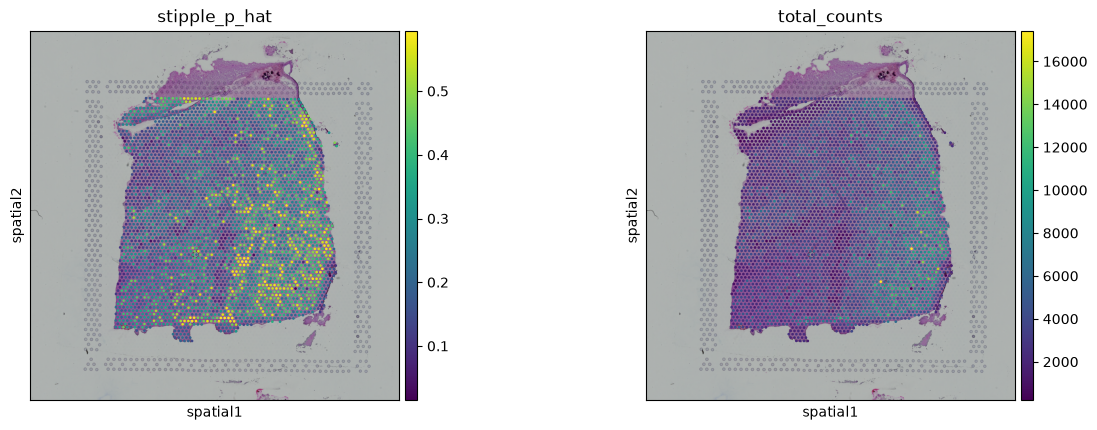

In [25]:
sq.pl.spatial_scatter(
    adata,
    color=['stipple_p_hat', 'total_counts']
)

In [22]:
adata_full = ad.read_h5ad(os.path.join(out_dir, 'adata.h5ad'))

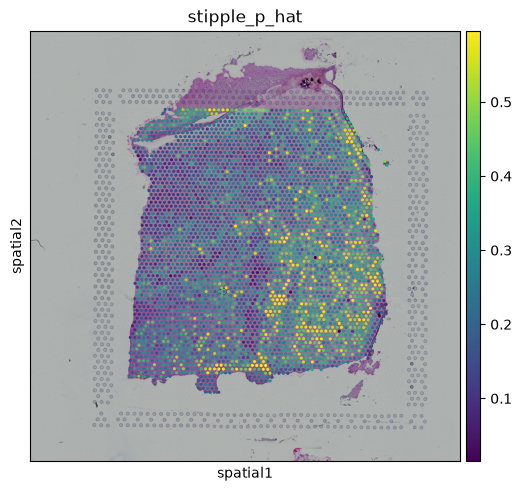

In [26]:
sq.pl.spatial_scatter(
    adata_full,
    color=['stipple_p_hat']
)